In [ ]:
#exp no:03                Logistic Regression

#ROLL NO: 230701244
#Name : PRAVEEN R


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

np.random.seed(42)
num_samples = 1000


X1 = np.random.normal(loc=5, scale=2, size=num_samples)

X2 = np.random.normal(loc=10, scale=3, size=num_samples)

X3 = np.random.normal(loc=0, scale=1, size=num_samples)


probabilities = 1 / (1 + np.exp(-(0.5 * X1 - 0.3 * X2 + 0.1 * X3 - 2)))
y = (probabilities > 0.5).astype(int)

df = pd.DataFrame({'Feature_1': X1, 'Feature_2': X2, 'Feature_3': X3, 'Target': y})

display(df.head())

,Feature_1,Feature_2,Feature_3,Target
0,5.993428,14.198066,-0.675178,0
1,4.723471,12.773901,-0.144519,0
2,6.295377,10.178891,-0.792420,0
3,8.046060,8.059190,-0.307962,0
4,4.531693,12.094670,-1.893615,0


In [3]:

X = df[['Feature_1', 'Feature_2', 'Feature_3']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Target distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution in test set:\n{y_test.value_counts(normalize=True)}")

Training set size: 700 samples
Test set size: 300 samples
Target distribution in training set:
Target
0    0.968571
1    0.031429
Name: proportion, dtype: float64
Target distribution in test set:
Target
0    0.97
1    0.03
Name: proportion, dtype: float64


In [4]:

model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [5]:

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Model Accuracy: 0.9833

Confusion Matrix:
[[287   4]
 [  1   8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       291
           1       0.67      0.89      0.76         9

    accuracy                           0.98       300
   macro avg       0.83      0.94      0.88       300
weighted avg       0.99      0.98      0.98       300



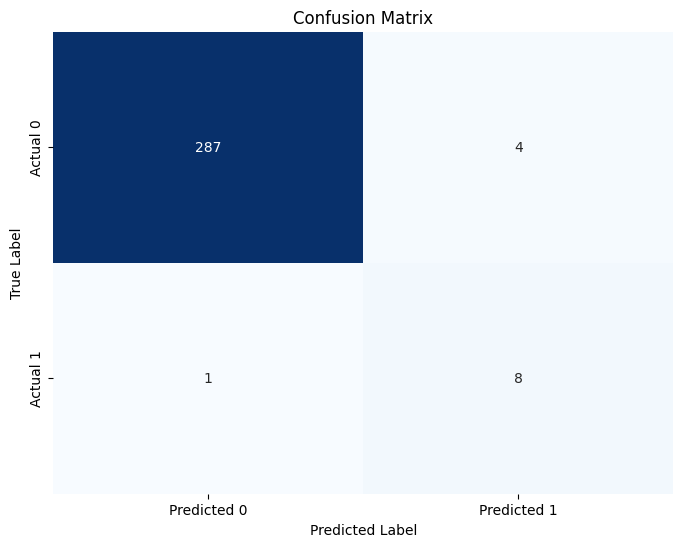

In [6]:

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()